In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re
from collections import Counter

Common words in product title users often interact with


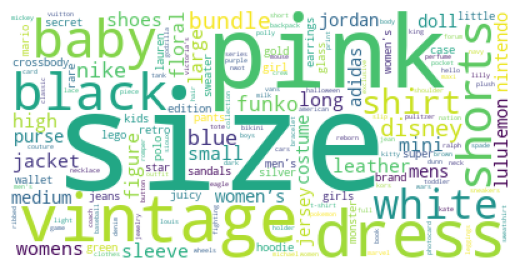

In [75]:
def count_words(path, chunk_size=100000, column='name'):
    word_count = Counter()
    chunk_obj = pd.read_csv(path, chunksize=chunk_size, usecols=['name'])

    for chunk in chunk_obj:
        for t in chunk[column]:
            word = str(t).lower().split()
            word_count.update(word)

    final_count = dict(word_count)

    for word in word_count:
        if word in STOPWORDS or len(word) < 4:
            del final_count[word]

    return final

final = count_words('datasets\\mercc_cleaned.csv')

print('Common words in product title users often interact with')

word_cloud = WordCloud(background_color='white')
word_cloud.generate_from_frequencies(final)
plt.figure(figsize=(5,3))
plt.axis('off')
plt.imshow(word_cloud)
plt.tight_layout(pad=0)
plt.show()